  0%|          | 0/1557 [00:00<?, ?it/s]

Total mask pixels: 32171.0


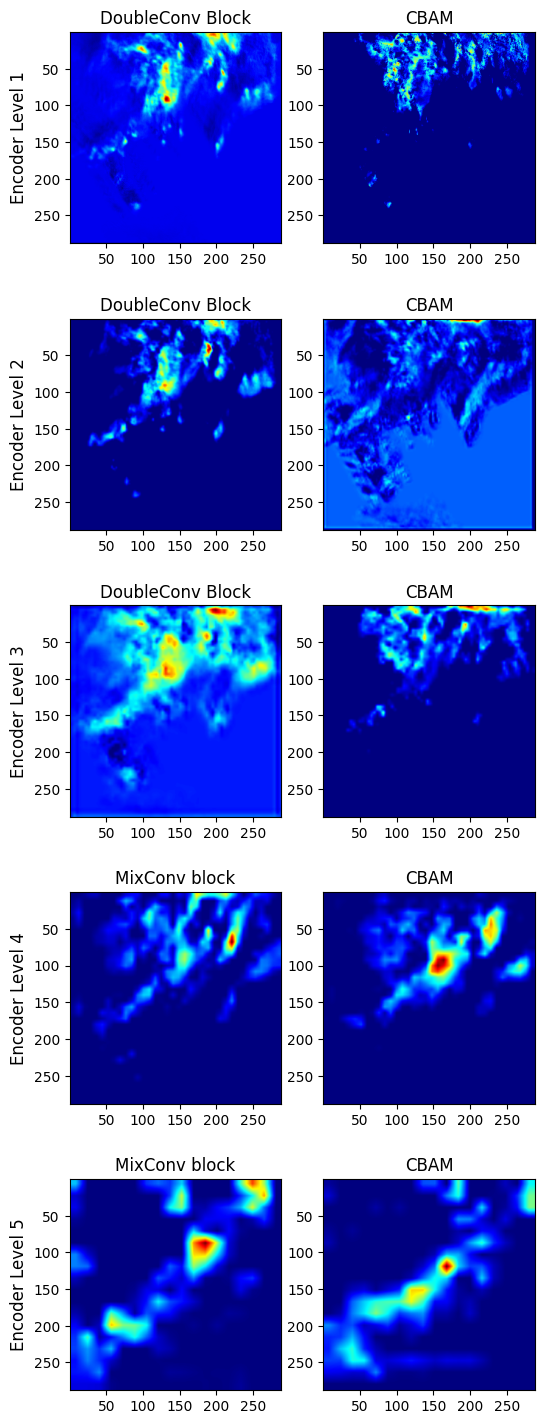

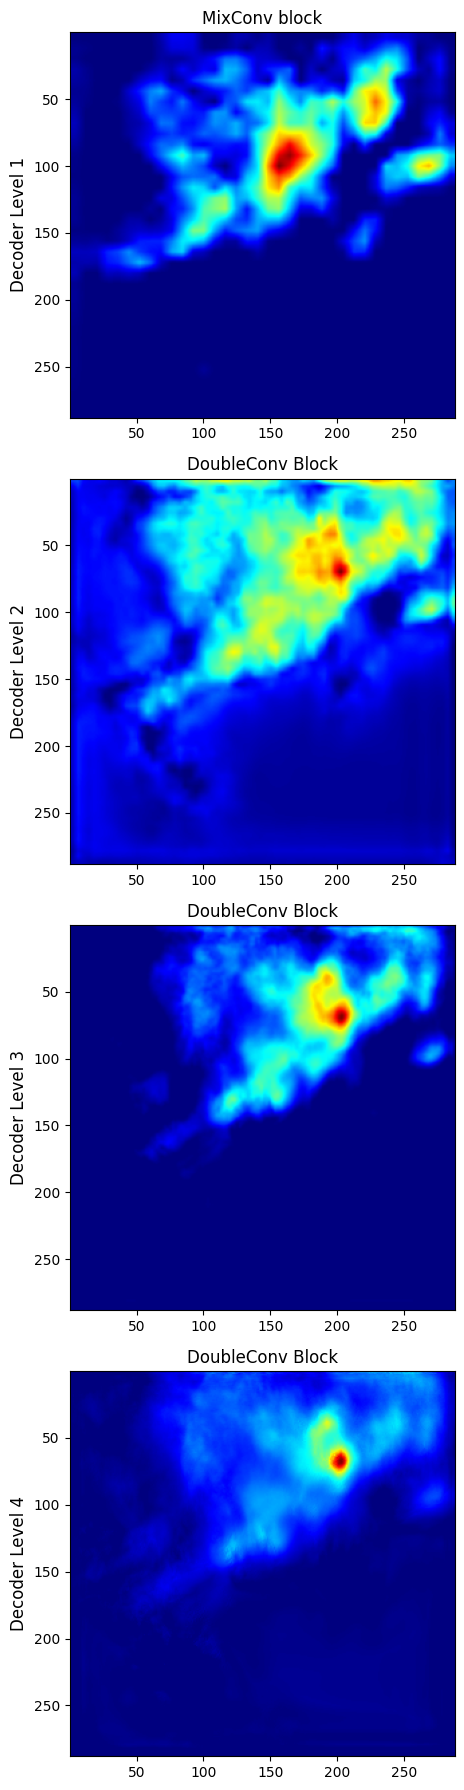

In [4]:
from torch.utils.data import DataLoader
import numpy as np
import os
import torch
from utils import dataset_precip
from tqdm import tqdm
from models import SmaAT_UNet_VQ_lightning
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam import GradCAM
from argparse import Namespace

warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')


class SemanticSegmentationTarget:
    def __init__(self, category, mask, device):
        self.category = category
        self.mask = torch.from_numpy(mask)
        if device == 'cuda':
            self.mask = self.mask.cuda()

    def __call__(self, model_output):
        return (model_output[self.category, :, :] * self.mask).sum()


def load_model(model_cls, model_folder, device, model_type="partialmixconv"):
    ckpts = [fn for fn in os.listdir(model_folder) if fn.endswith(".ckpt")]
    if not ckpts:
        raise FileNotFoundError(f"No .ckpt found in {model_folder!r}")
    ckpt_file = sorted(ckpts)[-1]
    ckpt_path = os.path.join(model_folder, ckpt_file)
    checkpoint = torch.load(ckpt_path, map_location=device)
    hparams_dict = checkpoint.get("hyper_parameters", {})
    if "model_type" not in hparams_dict:
        hparams_dict["model_type"] = model_type
    hparams_ns = Namespace(**hparams_dict)
    model = model_cls(hparams_ns)
    state_dict = checkpoint.get("state_dict", checkpoint)
    new_state_dict = {
        key[len("model."):] if key.startswith("model.") else key: val
        for key, val in state_dict.items()
    }
    model.load_state_dict(new_state_dict)
    model.eval()
    model.to(torch.device(device))
    return model


def get_segmentation_data(in_channels):
    dataset = dataset_precip.precipitation_maps_oversampled_h5(
        in_file=data_file,
        num_input_images=in_channels,
        num_output_images=6,
        train=False
    )
    return DataLoader(
        dataset,
        batch_size=1,
        shuffle=False,
        num_workers=0,
        pin_memory=True
    )


def run_cam(model, target_layers, device, in_channels):
    test_dl = get_segmentation_data(in_channels)
    x_ticks = [50, 100, 150, 200, 250]

    for x, _ in tqdm(test_dl, leave=False):
        x = x.to(torch.device(device))
        logits, _, _ = model(x)

        # build binary mask for Grad-CAM target
        mask = np.digitize(
            (logits[0][0] * 47.83 * 12).detach().cpu().numpy(),
            np.array([0.5]), right=True
        ).astype(np.float32)
        print("Total mask pixels:", mask.sum())

        # base grayscale→RGB image
        image = torch.stack([x[0][0]] * 3, dim=2).cpu().numpy()
        targets = [SemanticSegmentationTarget(0, mask, device)]

        # compute CAM images
        cam_image = []
        for layer in target_layers:
            with GradCAM(model=model, target_layers=layer) as cam:
                grayscale_cam = cam(input_tensor=x, targets=targets)[0]
                cam_image.append(
                    show_cam_on_image(image, grayscale_cam, use_rgb=True)
                )

        # select the 14 panels we actually plot
        display_idx = [1, 2, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
        cam_display = [cam_image[i] for i in display_idx]

        encoder_titles = [
            ['DoubleConv Block', 'CBAM'],
            ['DoubleConv Block', 'CBAM'],
            ['DoubleConv Block', 'CBAM'],
            ['MixConv block',    'CBAM'],
            ['MixConv block',    'CBAM']
        ]
        decoder_titles = [
            'MixConv block',
            'DoubleConv Block',
            'DoubleConv Block',
            'DoubleConv Block'
        ]

        # restore default subplot spacing
        mpl.rcParams.update(mpl.rcParamsDefault)

        # ENCODER FIGURE: 5 rows × 2 columns
        fig, axes = plt.subplots(5, 2, figsize=(6, 18))
        cam_idx = 0
        for row in range(5):
            for col in range(2):
                ax = axes[row, col]
                ax.imshow(cam_display[cam_idx], extent=[0, 288, 288, 0])
                ax.set_title(encoder_titles[row][col], fontsize=12)
                if col == 0:
                    ax.set_ylabel(f'Encoder Level {row + 1}', fontsize=12)
                ax.set_xticks(x_ticks)
                ax.set_yticks(x_ticks)
                cam_idx += 1

        # DECODER FIGURE: 4 rows × 1 column
        fig2, axes2 = plt.subplots(4, 1, figsize=(6, 18))
        for row in range(4):
            ax = axes2[row]
            ax.imshow(cam_display[cam_idx], extent=[0, 288, 288, 0])
            ax.set_title(decoder_titles[row], fontsize=12)
            ax.set_ylabel(f'Decoder Level {row + 1}', fontsize=12)
            ax.set_xticks(x_ticks)
            ax.set_yticks(x_ticks)
            cam_idx += 1

        plt.tight_layout()
        plt.show()
        # break


# ----------------------------------------------------------------------
# MAIN
# ----------------------------------------------------------------------
if __name__ == '__main__':
    hparams = {
        'model': 'SmaAT_UNet_VQ_MSE_PartialMixConv',
        'out_channels': 1,
        "n_channels": 12,
        "n_classes": 1,
        "reduction_ratio": 16,
        "kernels_per_layer": 1,
        "batch_size": 8,
        "learning_rate": 0.001,
        'gpus': -1,
        "lr_patience": 4,
        "es_patience": 15,
        "use_oversampled_dataset": True,
        "bilinear": True,
        "valid_size": 0.1,
        "dataset_folder": "data/precipitation/train_test_2016-2019_input-length_12_img-ahead_6_rain-threshold_50.h5",
        "resume_from_checkpoint": None
    }

    SmaAT_UNet_VQ = SmaAT_UNet_VQ_lightning.SmaAT_UNet_VQ
    model_folder = "checkpoints/comparison"
    data_file = 'data/precipitation/train_test_2016-2019_input-length_12_img-ahead_6_rain-threshold_50.h5'
    device = 'cpu'

    model = load_model(SmaAT_UNet_VQ, model_folder, device)

    target_layers = [
        [model.inc.double_conv[1]],
        [model.inc.double_conv[3]],
        [model.cbam1],
        [model.down1.maxpool_conv[1].double_conv[0]],
        [model.down1.maxpool_conv[1].double_conv[3]],
        [model.cbam2],
        [model.down2.maxpool_conv[1].double_conv[0]],
        [model.down2.maxpool_conv[1].double_conv[3]],
        [model.cbam3],
        [model.down3.maxpool_conv[1].mix1],
        [model.cbam4],
        [model.down4.maxpool_conv[1].mix1],
        [model.cbam5],
        [model.up1.conv.mix1],
        [model.up2.conv.double_conv[5]],
        [model.up3.conv.double_conv[5]],
        [model.up4.conv.double_conv[5]],
    ]

    run_cam(model, target_layers, device, hparams['n_channels'])
